# AIC/AICc-Based Model Selection and Multi-Model Inference

## Overview

The Akaike Information Criterion (AIC) estimates the expected relative Kullback-Leibler divergence between the fitted model and the true data-generating process. It balances goodness-of-fit against model complexity:

$$\text{AIC} = -2\log\hat{L} + 2k$$

where $\hat{L}$ is the maximised likelihood and $k$ is the number of estimated parameters.

**AICc** (corrected AIC) applies a finite-sample correction — use it whenever n/k < 40:
$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n-k-1}$$

**Interpreting differences (ΔAIC):**

| ΔAIC | Evidence against higher-AIC model |
|---|---|
| 0–2 | Substantial support; models plausible |
| 4–7 | Considerably less support |
| > 10 | Essentially no support |

**AIC vs. BIC vs. LOO-CV:**
- AIC: minimises prediction error for new observations from the same process; preferred for prediction
- BIC: consistent model selection (recovers true model as n→∞); preferred when parsimony matters and n is large
- LOO-CV: directly estimates predictive accuracy; preferred for Bayesian models (see `model_comparison_waic.ipynb`)

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(AICcmodavg)   # AICc, model averaging, evidence ratios
library(MuMIn)        # dredge(), model.avg()
library(broom)
library(patchwork)

set.seed(42)

n <- 150
aic_data <- tibble(
  nitrate     = rnorm(n, 3, 1.2),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.4),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(.35,.35,.30)),
                       levels=c("reference","restored","degraded")),
  richness    = round(
    22 - 2.5*nitrate + 1.2*water_qual - 0.5*distance_km +
    case_when(habitat=="reference"~2, habitat=="restored"~0, habitat=="degraded"~ -4) +
    rnorm(n, 0, 3)
  )
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'MuMIn'


The following objects are masked from 'package:AICcmodavg':

    AICc, DIC, importance


Warning messag

---

## Fit Candidate Models and Build a Model Selection Table

In [3]:
# Candidate models based on a priori biological hypotheses
# IMPORTANT: candidate models should be defined before seeing the data;
# post-hoc exploration of all possible subsets inflates false discovery rates

m1  <- lm(richness ~ nitrate,                                     data=aic_data)
m2  <- lm(richness ~ water_qual,                                   data=aic_data)
m3  <- lm(richness ~ nitrate + water_qual,                         data=aic_data)
m4  <- lm(richness ~ nitrate + water_qual + distance_km,           data=aic_data)
m5  <- lm(richness ~ nitrate + water_qual + habitat,               data=aic_data)
m6  <- lm(richness ~ nitrate + water_qual + distance_km + habitat, data=aic_data)
m7  <- lm(richness ~ nitrate + water_qual + distance_km + habitat +
                     elevation + slope_pct,                        data=aic_data)
m_null <- lm(richness ~ 1,                                         data=aic_data)

# Model names for the table
model_list  <- list(null=m_null, m1=m1, m2=m2, m3=m3, m4=m4,
                    m5=m5, m6=m6, m7=m7)
model_names <- names(model_list)

# ── AICc model selection table ────────────────────────────────────────────────
aic_table <- AICcmodavg::aictab(
  cand.set = model_list,
  modnames    = model_names,
  second.ord  = TRUE   # TRUE = AICc; FALSE = AIC
)
print(aic_table)
# Columns:
#   K:      number of parameters
#   AICc:   corrected AIC value
#   Delta_AICc: difference from best model
#   AICcWt: Akaike weight (posterior probability of model being best)
#   Cum.Wt: cumulative weight
#   LL:     log-likelihood


Model selection based on AICc:

     K   AICc Delta_AICc AICcWt Cum.Wt      LL
m6   7 796.93       0.00    0.9    0.9 -391.07
m7   9 801.29       4.35    0.1    1.0 -391.00
m5   6 819.35      22.42    0.0    1.0 -403.38
m4   5 851.09      54.16    0.0    1.0 -420.34
m3   4 865.27      68.34    0.0    1.0 -428.50
m1   3 891.52      94.58    0.0    1.0 -442.68
m2   3 918.89     121.96    0.0    1.0 -456.37
null 2 932.89     135.96    0.0    1.0 -464.41



---

## Akaike Weights and Evidence Ratios

# A tibble: 8 × 5
  Modnames     K Delta_AICc AICcWt evidence_ratio
  <chr>    <dbl>      <dbl>  <dbl>          <dbl>
1 m6           7       0     0.898            1  
2 m7           9       4.35  0.102            8.8
3 m5           6      22.4   0              Inf  
4 m4           5      54.2   0              Inf  
5 m3           4      68.3   0              Inf  
6 m1           3      94.6   0              Inf  
7 m2           3     122.    0              Inf  
8 null         2     136.    0              Inf  


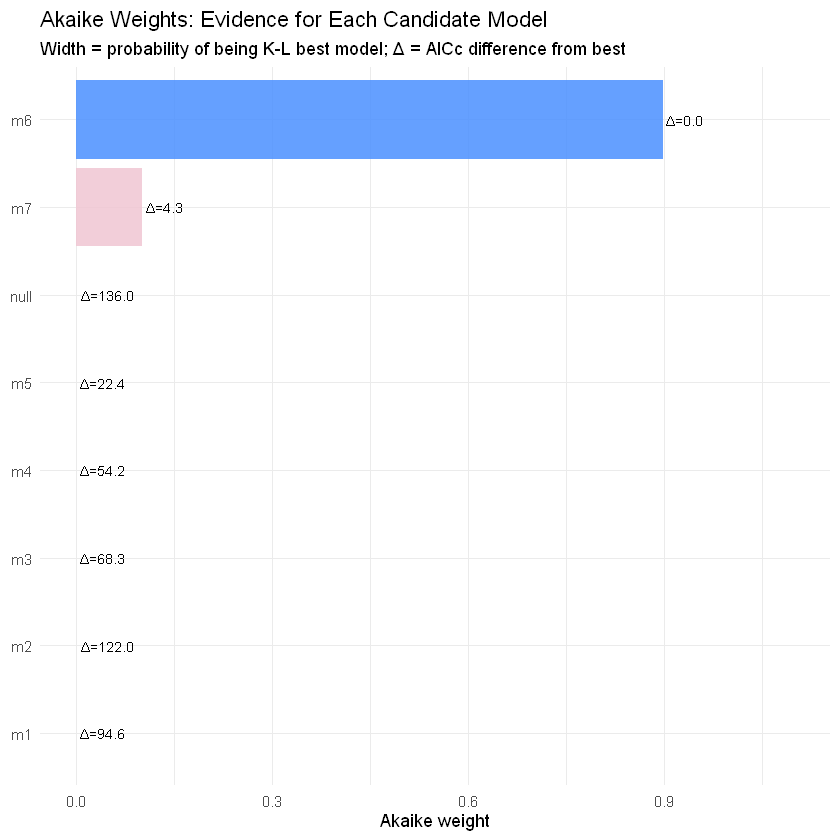

In [4]:
# Akaike weights: w_i = exp(-0.5 * delta_i) / sum(exp(-0.5 * delta_j))
# Interpretation: probability that model i is the K-L best model
#   given the data and the candidate set

wt_df <- as_tibble(aic_table) %>%
  select(Modnames, K, Delta_AICc, AICcWt) %>%
  arrange(Delta_AICc) %>%
  mutate(AICcWt = round(AICcWt, 4),
         Delta_AICc = round(Delta_AICc, 2))

# Evidence ratio: w_best / w_i — how many times more support has the best model
best_wt <- wt_df$AICcWt[1]
wt_df   <- wt_df %>% mutate(evidence_ratio = round(best_wt / AICcWt, 1))
print(wt_df)

# ── Visualise weights ─────────────────────────────────────────────────────────
ggplot(wt_df, aes(x=AICcWt,
                  y=fct_reorder(Modnames, AICcWt),
                  fill=AICcWt)) +
  geom_col(alpha=0.85) +
  geom_text(aes(label=sprintf("Δ=%.1f", Delta_AICc)), hjust=-0.1, size=3) +
  scale_fill_gradient(low="#ffcccc", high="#4a8fff", guide="none") +
  scale_x_continuous(limits=c(0, 1.1)) +
  labs(title="Akaike Weights: Evidence for Each Candidate Model",
       subtitle="Width = probability of being K-L best model; Δ = AICc difference from best",
       x="Akaike weight", y=NULL) +
  theme_minimal()

---

## Model Averaging

In [9]:
# ── Full model average (all models, weighted) ─────────────────────────────────
avg_full <- AICcmodavg::modavg(
  cand.set   = model_list,   # cand.set, not cand.models
  modnames   = model_names,
  parm       = "nitrate",
  second.ord = TRUE
)
cat("Model-averaged coefficient for nitrate:\n")
print(avg_full)

# ── Variable importance ───────────────────────────────────────────────────────
parms <- c("nitrate", "water_qual", "distance_km",
           "habitatrestored", "habitatdegraded",
           "elevation", "slope_pct")

importance_table <- map_dfr(parms, function(p) {
  tryCatch({
    imp <- AICcmodavg::importance(
      cand.set   = model_list,
      modnames   = model_names,
      parm       = p,
      second.ord = TRUE
    )
    tibble(parameter = p, w_plus = imp$w.plus)
  }, error = function(e) {
    # parameter not in any model — importance = 0
    tibble(parameter = p, w_plus = 0)
  })
}) %>% arrange(desc(w_plus))

cat("\nVariable importance (summed Akaike weights):\n")
print(importance_table)

Model-averaged coefficient for nitrate:

Multimodel inference on "nitrate" based on AICc

AICc table used to obtain model-averaged estimate:

   K   AICc Delta_AICc AICcWt Estimate   SE
m1 3 891.52      94.58    0.0    -2.23 0.32
m3 4 865.27      68.34    0.0    -2.36 0.29
m4 5 851.09      54.16    0.0    -2.19 0.28
m5 6 819.35      22.42    0.0    -2.49 0.25
m6 7 796.93       0.00    0.9    -2.34 0.23
m7 9 801.29       4.35    0.1    -2.33 0.23

Model-averaged estimate: -2.34 
Unconditional SE: 0.23 
95% Unconditional confidence interval: -2.79, -1.89


Variable importance (summed Akaike weights):
# A tibble: 7 × 2
  parameter       w_plus
  <chr>            <dbl>
1 nitrate              0
2 water_qual           0
3 distance_km          0
4 habitatrestored      0
5 habitatdegraded      0
6 elevation            0
7 slope_pct            0


---

## AIC vs. BIC vs. Adjusted R²

In [10]:
# Compare criteria across candidate models
criteria_df <- map_dfr(names(model_list), function(nm) {
  m   <- model_list[[nm]]
  gl  <- glance(m)
  tibble(
    model    = nm,
    k        = length(coef(m)),
    AIC      = AIC(m),
    AICc     = AICcmodavg::AICc(m),
    BIC      = BIC(m),
    adj_r2   = gl$adj.r.squared
  )
}) %>%
  mutate(
    delta_AIC  = AIC  - min(AIC),
    delta_BIC  = BIC  - min(BIC),
    delta_AICc = AICc - min(AICc)
  ) %>%
  arrange(AICc) %>%
  mutate(across(where(is.numeric), ~round(.x, 2)))

print(criteria_df)
# Note: AIC and AICc often agree on rankings;
# BIC tends to favour simpler models, especially at larger n;
# adjusted R² does not account for prediction on new data

# A tibble: 8 × 9
  model     k   AIC  AICc   BIC adj_r2 delta_AIC delta_BIC delta_AICc
  <chr> <dbl> <dbl> <dbl> <dbl>  <dbl>     <dbl>     <dbl>      <dbl>
1 m6        6  796.  797.  817.   0.61      0         0          0   
2 m7        8  800   801.  827.   0.61      3.86      9.88       4.35
3 m5        5  819.  819.  837.   0.54     22.6      19.6       22.4 
4 m4        4  851.  851.  866.   0.43     54.5      48.5       54.2 
5 m3        3  865   865.  877.   0.37     68.8      59.8       68.3 
6 m1        2  891.  892.  900.   0.25     95.2      83.2       94.6 
7 m2        2  919.  919.  928.   0.1     123.      111.       122.  
8 null      1  933.  933.  939.   0       137.      122.       136.  


---

## Common Pitfalls

**1. Using AIC as a hypothesis test**  
ΔAIC is not a p-value. A model with ΔAIC = 3 is not "significantly worse" — it has moderately less support under the K-L framework. AIC is a measure of relative evidence within the candidate set, not an absolute test of model adequacy.

**2. Using AIC instead of AICc with small samples**  
AIC underpenalises complex models in small samples. Use AICc whenever n/k < 40 (where k is the number of parameters in the most complex candidate model). For most ecological datasets, AICc should be the default.

**3. Data dredging: fitting all possible subsets and selecting by AIC**  
Using `MuMIn::dredge()` to exhaustively search all 2^p subsets capitalises on chance. With p=10 predictors, there are 1024 candidate models — the best-AIC model is almost certainly overfit and the variable importance values are inflated. AIC model selection requires a biologically motivated candidate set defined before seeing the data.

**4. Comparing models with different response distributions or data subsets**  
AIC values are only comparable across models that use the same likelihood function applied to identical data. You cannot compare an lm() and a glm(Poisson) using AIC, nor models fitted to different subsets of the data (e.g., after different missing-data exclusions).

**5. Interpreting variable importance from model averaging as a significance test**  
Summed Akaike weights reflect how consistently a variable appears in competitive models — they are not equivalent to p-values or effect sizes. A variable with weight 0.9 is not necessarily "more important" than one with weight 0.6 in any inferential sense.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*